___

# Machine Learning in Geosciences ] 
Department of Applied Geoinformatics and Carthography, Charles University

Lukas Brodsky lukas.brodsky@natur.cuni.cz


## Deep Learning - Convolutional Neural Networks - Segmentation

Task: This notebook presents a CNN segmentation model programmed using the PyTorch library https://pytorch.org on the example of simulated images containing 3 shapes in random position. 

Architecture: U-Net

**Tasks**: 
    
 1. Develop a complete workflow with the CNN architecture for object segmentation.
    
 2. Change the noise level from 0.1 to 0.5 and 0.9 and evaluate the learning accuracy.

### Architektura U-Net

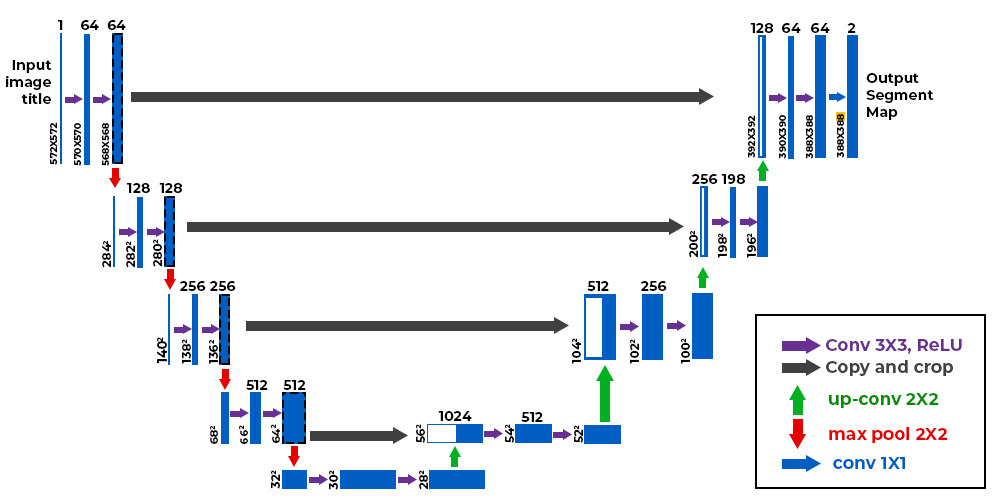

#### Main steps of the modelling workflow 
1. Loading the dataset
2. Create iterable dataset
3. Create model class
4. Instantiate model class
5. Instantiate loss class
6. Instantiate optimizer class
7. Model training 

In [83]:
import numpy as np
np.random.seed(42) 
import matplotlib.pyplot as plt
import time 

# PyTorch imports 
import torch

import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from torch.autograd import Variable

from torchsummary import summary
# from torchinfo import summary
import segmentation_models_pytorch as smp

In [ ]:
# pip install segmentation-models-pytorch 

### Simulated data 

In [65]:
# Skript pro simulaci dat 
from simulate_images import generate_image_shapes

In [3]:
# Generating dat
height, width, count = 32, 32, 9
noise = 0.2
X, Y, y_label = generate_image_shapes(height, width, count, noise)

In [4]:
X.shape

(9, 1, 32, 32)

In [5]:
torch.squeeze(torch.tensor(X)).shape

torch.Size([9, 32, 32])

In [6]:
Y.shape

(9, 1, 32, 32)

In [7]:
np.unique(y_label)

array([0, 1, 2])

Label: 0


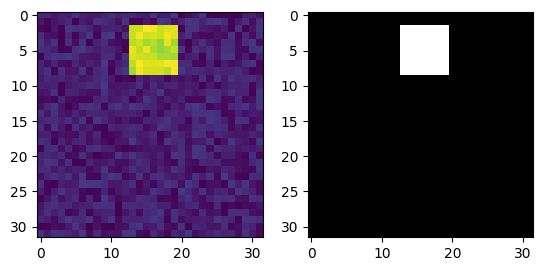

In [8]:
image_no=1
print(f'Label: {y_label[image_no]}')
plt.subplot(1, 2, 1)
plt.imshow(X[image_no][0,:,:])
plt.subplot(1, 2, 2)
plt.imshow(Y[image_no][0,:,:], cmap='gray') 

Label: 2


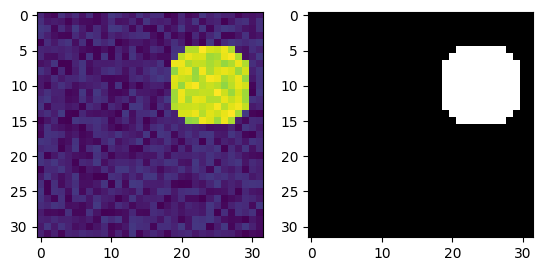

In [9]:
image_no=2
print(f'Label: {y_label[image_no]}')
plt.subplot(1, 2, 1)
plt.imshow(X[image_no][0,:,:])
plt.subplot(1, 2, 2)
plt.imshow(Y[image_no][0,:,:], cmap='gray') 

Label: 1


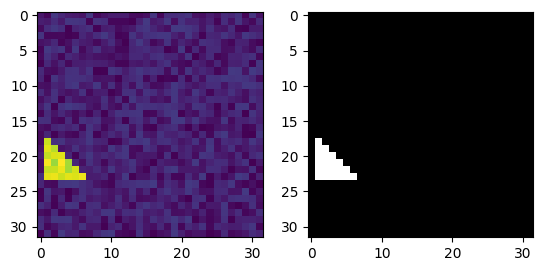

In [66]:
image_no=7
print(f'Label: {y_label[image_no]}')
plt.subplot(1, 2, 1)
plt.imshow(X[image_no][0,:,:])
plt.subplot(1, 2, 2)
plt.imshow(Y[image_no][0,:,:], cmap='gray') 

### 1. Class for loading the dataset

In [84]:
class SimDataset(Dataset):
    def __init__(self, height, width, count, noise, transform=None):
        self.input_images, self.target_masks, self.target_labels= generate_image_shapes(height, width, 
                                                                                        count, noise)
        self.transform = transform

    def __len__(self):
        return len(self.input_images)

    def __getitem__(self, idx):
        image = self.input_images[idx]
        # image typu float
        image_torch = torch.from_numpy(image).float()
        image_torch_rgb = torch.squeeze(torch.stack((image_torch,image_torch,image_torch),dim=0))
        # segmentační maska
        mask = self.target_masks[idx]
        # segmentacni maska typu long (int64)
        mask_torch = torch.squeeze(torch.from_numpy(mask).long())
        # kód tvaru 
        label= self.target_labels[idx] 
    
        if self.transform:
            image = self.transform(image)

        return [image_torch_rgb, mask_torch, label]


In [95]:
# test 
height, width, count = 32, 32, 9 
noise = 0.1
train_size = 1 
sd = SimDataset(height, width, train_size, noise) 

In [96]:
dl =  DataLoader(sd, batch_size=1, shuffle=True, num_workers=0)

In [97]:
dl

In [98]:
sample, msk, lbl = next(iter(dl))
# sample[0].shape

TypeError: 'int' object is not callable

In [14]:
msk.shape

torch.Size([1, 32, 32])

### 2. Create iterable dataset

In [59]:
def get_data_loaders(height, width, noise, train_size, test_size, batch_size=5):

    # height, width, count = 64, 64
    train_set = SimDataset(height, width, train_size, noise) # , transform = trans
    test_set = SimDataset(height, width, test_size, noise) # , transform = trans


    train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    test_dataloader = DataLoader(test_set, batch_size=batch_size, shuffle=True, num_workers=0)


    return train_dataloader, test_dataloader


In [60]:
### Příprava dat do dataloaderu (iterátor) 
batch_size = 9
height, width = 32, 32
noise = 0.1
train_dataloader, test_dataloader = get_data_loaders(height, width, noise, train_size=500, test_size=500, 
                                                     batch_size=batch_size)

In [61]:
sample = next(iter(train_dataloader))
image, mask, label = sample

TypeError: 'int' object is not callable

In [18]:
image.dtype


torch.float32

In [19]:
mask.dtype

torch.int64

###  3. Create model class

### Segmentation models
https://smp.readthedocs.io/en/latest/index.html 

**Segmentation model is based on PyTorch nn.Module:** 



`
import segmentation_models_pytorch as smp
model = smp.Unet(
    encoder_name=„resnet34“,     # emcoder, mobilenet_v2 or efficientnet-b7, ...
    encoder_weights=„imagenet“,  # weights initialization 
    in_channels=1,               # input channels (1 for grayscale images, 3 for RGB)
    classes=3,                   # output (number of classes)
)
`

**Model learning** 

`
for images, gt_masks in dataloader:

    predicted_mask = model(image)
    loss = loss_fn(predicted_mask, gt_masks)

    loss.backward()
    optimizer.step()
`

### 4. Instantiate model class

In [45]:
model = smp.Unet('mobilenet_v2', encoder_weights='imagenet', classes=2, 
                 activation=None, encoder_depth=4, decoder_channels=[256, 128, 64, 32])


In [25]:
# smp.__version__

'0.3.3'

In [28]:
# summary(model)

In [37]:
# summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 16, 16]             864
       BatchNorm2d-2           [-1, 32, 16, 16]              64
             ReLU6-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 32, 16, 16]             288
       BatchNorm2d-5           [-1, 32, 16, 16]              64
             ReLU6-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 16, 16, 16]             512
       BatchNorm2d-8           [-1, 16, 16, 16]              32
  InvertedResidual-9           [-1, 16, 16, 16]               0
           Conv2d-10           [-1, 96, 16, 16]           1,536
      BatchNorm2d-11           [-1, 96, 16, 16]             192
            ReLU6-12           [-1, 96, 16, 16]               0
           Conv2d-13             [-1, 96, 8, 8]             864
      BatchNorm2d-14             [-1, 9

In [38]:
model

Unet(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1

In [22]:
# Prarametry modelu 
params = [p.numel() for p in model.parameters() if p.requires_grad]
print(params)

[864, 32, 32, 288, 32, 32, 512, 16, 16, 1536, 96, 96, 864, 96, 96, 2304, 24, 24, 3456, 144, 144, 1296, 144, 144, 3456, 24, 24, 3456, 144, 144, 1296, 144, 144, 4608, 32, 32, 6144, 192, 192, 1728, 192, 192, 6144, 32, 32, 6144, 192, 192, 1728, 192, 192, 6144, 32, 32, 6144, 192, 192, 1728, 192, 192, 12288, 64, 64, 24576, 384, 384, 3456, 384, 384, 24576, 64, 64, 24576, 384, 384, 3456, 384, 384, 24576, 64, 64, 24576, 384, 384, 3456, 384, 384, 24576, 64, 64, 24576, 384, 384, 3456, 384, 384, 36864, 96, 96, 55296, 576, 576, 5184, 576, 576, 55296, 96, 96, 55296, 576, 576, 5184, 576, 576, 55296, 96, 96, 55296, 576, 576, 5184, 576, 576, 92160, 160, 160, 153600, 960, 960, 8640, 960, 960, 153600, 160, 160, 153600, 960, 960, 8640, 960, 960, 153600, 160, 160, 153600, 960, 960, 8640, 960, 960, 307200, 320, 320, 409600, 1280, 1280, 294912, 256, 256, 589824, 256, 256, 322560, 128, 128, 147456, 128, 128, 82944, 64, 64, 36864, 64, 64, 18432, 32, 32, 9216, 32, 32, 576, 2]


In [39]:
# for p in model.parameters():
#     print(p)

###  5. Instantiate loss class

In [46]:
# Cross-Entropy Loss
criterion = nn.CrossEntropyLoss()

### 6. Instantiate optimizer class

In [47]:
# optimizer 
learning_rate = 0.001 

# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
# Adam()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

### 7. Model training

In [48]:
# Training 
start = time.time()

# epochs (TODO: more after test run )
num_epochs = 3

# loss_history = [] 
train_loss, test_loss = [], []

iter = 0
for epoch in range(num_epochs):
    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train(True)  # trainin mode 
            dataloader = train_dataloader
        else:
            model.train(False)  # trainin mode 
            dataloader = test_dataloader

        step = 0 
        # data iteration 
        for x, masks, y in dataloader:
            step += 1
            x = Variable(x)
            y = Variable(masks)

            # forward step 
            if phase == 'train':
                # clear gradients 
                optimizer.zero_grad()
                outputs = model(x)
                # TODO: convert to float 
                loss = criterion(outputs, y)                

                # backpropagation 
                loss.backward() 
                # optimalization step
                optimizer.step()  

            else:
                # testing  
                with torch.no_grad():
                    outputs = model(x)  
                    # Convert y to LONG!!! 
                    loss = criterion(outputs, y.long()) 
            
            # accuracy evaluation 
            if phase=='train': 
                train_loss.append(loss)
                # if step % 10 == 0:
                print('Epocha: {}  training loss: {} '.format(epoch, loss)) 
            else: 
                test_loss.append(loss)
                # if step % 10 == 0:
                print('Epocha: {}  testing loss: {} '.format(epoch, loss)) 
                                        

print('---')
time_elapsed = time.time() - start
print('Training finished in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))        

Epocha: 0  training loss: 1.5399250984191895 
Epocha: 0  training loss: 1.1969956159591675 
Epocha: 0  training loss: 0.9419465661048889 
Epocha: 0  training loss: 0.7859011292457581 
Epocha: 0  training loss: 0.5543205738067627 
Epocha: 0  training loss: 0.6141972541809082 
Epocha: 0  training loss: 0.41362571716308594 
Epocha: 0  training loss: 0.34636053442955017 
Epocha: 0  training loss: 0.2695143520832062 
Epocha: 0  training loss: 0.24415278434753418 
Epocha: 0  training loss: 0.20380234718322754 
Epocha: 0  training loss: 0.19225120544433594 
Epocha: 0  training loss: 0.14392437040805817 
Epocha: 0  training loss: 0.136216402053833 
Epocha: 0  training loss: 0.12104412913322449 
Epocha: 0  training loss: 0.10985398292541504 
Epocha: 0  training loss: 0.08980085700750351 
Epocha: 0  training loss: 0.08503973484039307 
Epocha: 0  training loss: 0.07913485914468765 
Epocha: 0  training loss: 0.07911459356546402 
Epocha: 0  training loss: 0.07885567843914032 
Epocha: 0  training lo

#### Plot training and testing evolution 

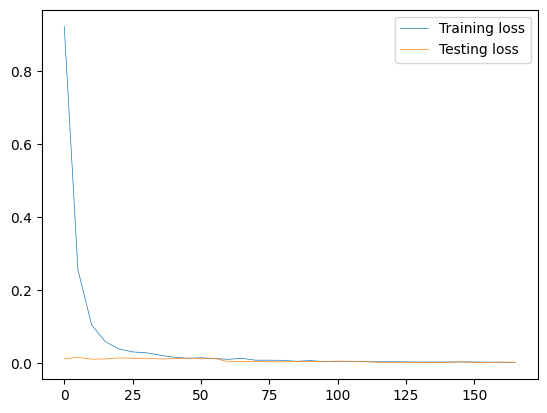

In [44]:
plt.plot(range(0, len(train_loss), 5), [l.item() for l in train_loss[::5]], 
         linewidth=0.5, label='Training loss')
plt.plot(range(0, len(test_loss), 5), [l.item() for l in test_loss[::5]], 
         linewidth=0.5, label='Testing loss')
plt.legend()

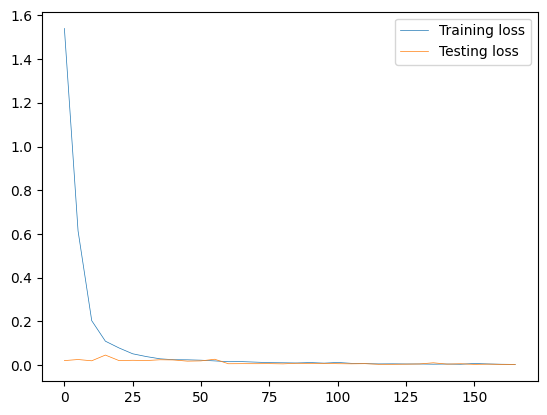

In [49]:
plt.plot(range(0, len(train_loss), 5), [l.item() for l in train_loss[::5]], 
         linewidth=0.5, label='Training loss')
plt.plot(range(0, len(test_loss), 5), [l.item() for l in test_loss[::5]], 
         linewidth=0.5, label='Testing loss')
plt.legend()

In [100]:
model.train(False) 

Unet(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1

In [103]:
for x, masks, y in test_dataloader:
    x = Variable(x)
    y = Variable(masks)
    break

In [104]:
with torch.no_grad():
    outputs = model(x)  

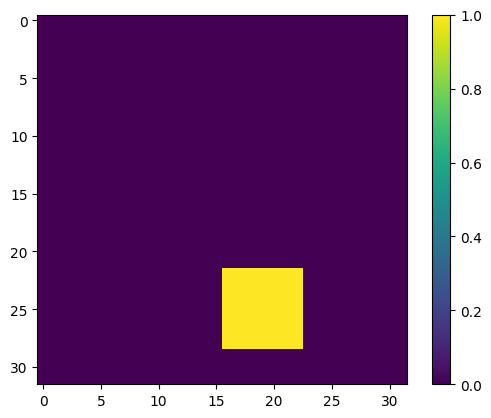

In [126]:
plt.imshow(outputs[2, 1, :, :] > 2)
plt.colorbar()

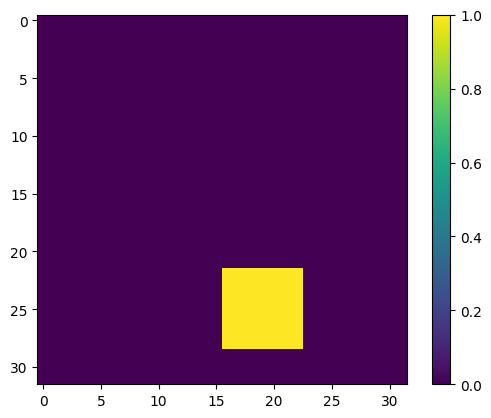

In [125]:
plt.imshow(masks[2, :, :])
plt.colorbar()

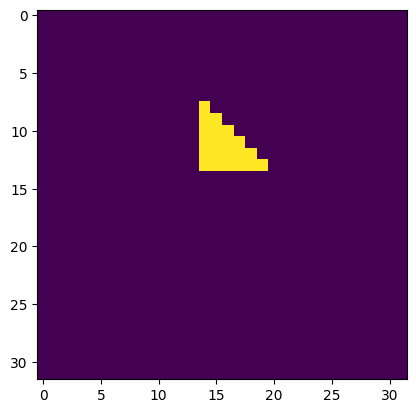